In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from utils import create_monthly_sales_dataframe

# Options d'affichage
pd.set_option("display.max_columns", None)
sns.set()  # style par défaut

# Dossier data
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)


In [30]:
# 1) Generate initial monthly sales data
df_initial = create_monthly_sales_dataframe(start_year=2025)

# Aperçu
df_initial


,Date,Product_A,Product_B,Product_C,Product_D
0,2025-01-01,88,34,40,21
1,2025-02-01,78,30,55,40
2,2025-03-01,64,79,23,13
3,2025-04-01,92,51,52,42
4,2025-05-01,57,46,40,41
5,2025-06-01,70,47,23,31
6,2025-07-01,88,57,43,45
7,2025-08-01,68,32,42,14
8,2025-09-01,72,76,45,25
9,2025-10-01,60,60,23,11


In [31]:
initial_path = DATA_DIR / "initial.csv"
df_initial.to_csv(initial_path, index=False)
initial_path


PosixPath('data/initial.csv')

In [62]:
df = df_initial.copy()

# Extraire le nom du mois et le numéro de mois
df["Month_Name"] = df["Date"].dt.strftime("%B")   # ex: 'January'
df["Month_Number"] = df["Date"].dt.month         # 1 ... 12

# Définir le trimestre
def assign_quarter(month_num: int) -> str:
    if month_num in [1, 2, 3]:
        return "Q1"
    elif month_num in [4, 5, 6]:
        return "Q2"
    elif month_num in [7, 8, 9]:
        return "Q3"
    else:
        return "Q4"

df["Quarter"] = df["Month_Number"].apply(assign_quarter)

df.head()


,Date,Product_A,Product_B,Product_C,Product_D,Month_Name,Month_Number,Quarter
0,2025-01-01,88,34,40,21,January,1,Q1
1,2025-02-01,78,30,55,40,February,2,Q1
2,2025-03-01,64,79,23,13,March,3,Q1
3,2025-04-01,92,51,52,42,April,4,Q2
4,2025-05-01,57,46,40,41,May,5,Q2


In [34]:
df

,Date,Product_A,Product_B,Product_C,Product_D,Month_Name,Month_Number,Quarter,Total_Sales,Average_Sales
0,2025-01-01,88,34,40,21,January,1,Q1,183,45.75
1,2025-02-01,78,30,55,40,February,2,Q1,203,50.75
2,2025-03-01,64,79,23,13,March,3,Q1,179,44.75
3,2025-04-01,92,51,52,42,April,4,Q2,237,59.25
4,2025-05-01,57,46,40,41,May,5,Q2,184,46.00
5,2025-06-01,70,47,23,31,June,6,Q2,171,42.75
6,2025-07-01,88,57,43,45,July,7,Q3,233,58.25
7,2025-08-01,68,32,42,14,August,8,Q3,156,39.00
8,2025-09-01,72,76,45,25,September,9,Q3,218,54.50
9,2025-10-01,60,60,23,11,October,10,Q4,154,38.50


In [35]:
df["Month_over_Month_Growth"] = df["Total_Sales"].pct_change() * 100

In [36]:
df

,Date,Product_A,Product_B,Product_C,Product_D,Month_Name,Month_Number,Quarter,Total_Sales,Average_Sales,Month_over_Month_Growth
0,2025-01-01,88,34,40,21,January,1,Q1,183,45.75,NaN
1,2025-02-01,78,30,55,40,February,2,Q1,203,50.75,10.928962
2,2025-03-01,64,79,23,13,March,3,Q1,179,44.75,-11.822660
3,2025-04-01,92,51,52,42,April,4,Q2,237,59.25,32.402235
4,2025-05-01,57,46,40,41,May,5,Q2,184,46.00,-22.362869
5,2025-06-01,70,47,23,31,June,6,Q2,171,42.75,-7.065217
6,2025-07-01,88,57,43,45,July,7,Q3,233,58.25,36.257310
7,2025-08-01,68,32,42,14,August,8,Q3,156,39.00,-33.047210
8,2025-09-01,72,76,45,25,September,9,Q3,218,54.50,39.743590
9,2025-10-01,60,60,23,11,October,10,Q4,154,38.50,-29.357798


In [59]:
# 1) Créer les colonnes Max_Sales_Product et Min_Sales_Product
df["Max_Sales_Product"] = df[product_cols].idxmax(axis=1)
df["Min_Sales_Product"] = df[product_cols].idxmin(axis=1)

# 2) Nettoyer le nom (enlever "Product_")
df["Max_Sales_Product"] = df["Max_Sales_Product"].str.replace("Product_", "")
df["Min_Sales_Product"] = df["Min_Sales_Product"].str.replace("Product_", "")
df

,Date,Product_A,Product_B,Product_C,Product_D,Max_Sales_Product,Min_Sales_Product
0,2025-01-01,88,34,40,21,A,D
1,2025-02-01,78,30,55,40,A,B
2,2025-03-01,64,79,23,13,B,D
3,2025-04-01,92,51,52,42,A,D
4,2025-05-01,57,46,40,41,A,C
5,2025-06-01,70,47,23,31,A,C
6,2025-07-01,88,57,43,45,A,C
7,2025-08-01,68,32,42,14,A,D
8,2025-09-01,72,76,45,25,B,D
9,2025-10-01,60,60,23,11,A,D


In [38]:
final_path = DATA_DIR / "final.csv"
df.to_csv(final_path, index=False)
final_path

PosixPath('data/final.csv')

In [39]:
# Pivot: mean sales by quarter and product
pivot_mean = df.pivot_table(
    index="Quarter",
    values=product_cols + ["Total_Sales"],
    aggfunc="mean"
).reset_index()

pivot_mean


,Quarter,Product_A,Product_B,Product_C,Product_D,Total_Sales
0,Q1,76.666667,47.666667,39.333333,24.666667,188.333333
1,Q2,73.000000,48.000000,38.333333,38.000000,197.333333
2,Q3,76.000000,55.000000,43.333333,28.000000,202.333333
3,Q4,64.333333,47.666667,24.333333,17.666667,154.000000


In [40]:
pivot_sum = df.pivot_table(
    index="Quarter",
    values=product_cols + ["Total_Sales"],
    aggfunc="sum"
).reset_index()

pivot_sum


,Quarter,Product_A,Product_B,Product_C,Product_D,Total_Sales
0,Q1,230,143,118,74,565
1,Q2,219,144,115,114,592
2,Q3,228,165,130,84,607
3,Q4,193,143,73,53,462


In [41]:
pivot_mean["Metric_Type"] = "Mean"
pivot_sum["Metric_Type"] = "Sum"

pivot_output = pd.concat([pivot_mean, pivot_sum], ignore_index=True)

output_path = DATA_DIR / "output.csv"
pivot_output.to_csv(output_path, index=False)
pivot_output

,Quarter,Product_A,Product_B,Product_C,Product_D,Total_Sales,Metric_Type
0,Q1,76.666667,47.666667,39.333333,24.666667,188.333333,Mean
1,Q2,73.000000,48.000000,38.333333,38.000000,197.333333,Mean
2,Q3,76.000000,55.000000,43.333333,28.000000,202.333333,Mean
3,Q4,64.333333,47.666667,24.333333,17.666667,154.000000,Mean
4,Q1,230.000000,143.000000,118.000000,74.000000,565.000000,Sum
5,Q2,219.000000,144.000000,115.000000,114.000000,592.000000,Sum
6,Q3,228.000000,165.000000,130.000000,84.000000,607.000000,Sum
7,Q4,193.000000,143.000000,73.000000,53.000000,462.000000,Sum


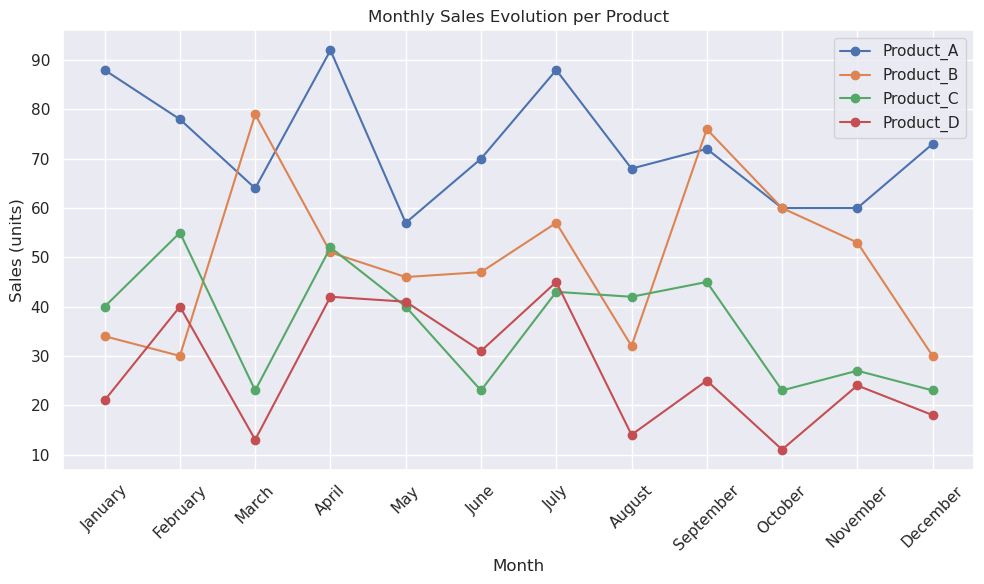

In [42]:
plt.figure(figsize=(10, 6))
for col in product_cols:
    plt.plot(df["Month_Number"], df[col], marker="o", label=col)

plt.xticks(df["Month_Number"], df["Month_Name"], rotation=45)
plt.xlabel("Month")
plt.ylabel("Sales (units)")
plt.title("Monthly Sales Evolution per Product")
plt.legend()
plt.tight_layout()
plt.show()

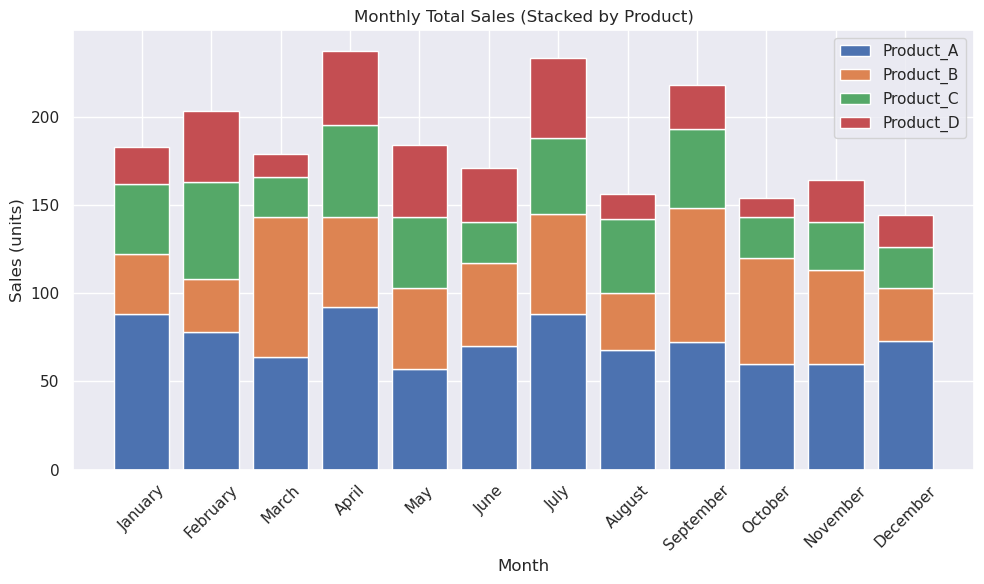

In [43]:
plt.figure(figsize=(10, 6))
bottom = np.zeros(len(df))

for col in product_cols:
    plt.bar(df["Month_Name"], df[col], bottom=bottom, label=col)
    bottom += df[col].values

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Sales (units)")
plt.title("Monthly Total Sales (Stacked by Product)")
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
best_month_idx = df["Total_Sales"].idxmax()
best_month_name = df.loc[best_month_idx, "Month_Name"]
best_month_value = df.loc[best_month_idx, "Total_Sales"]

print("Best month:", best_month_name, "-", best_month_value, "units")

Best month: April - 237 units


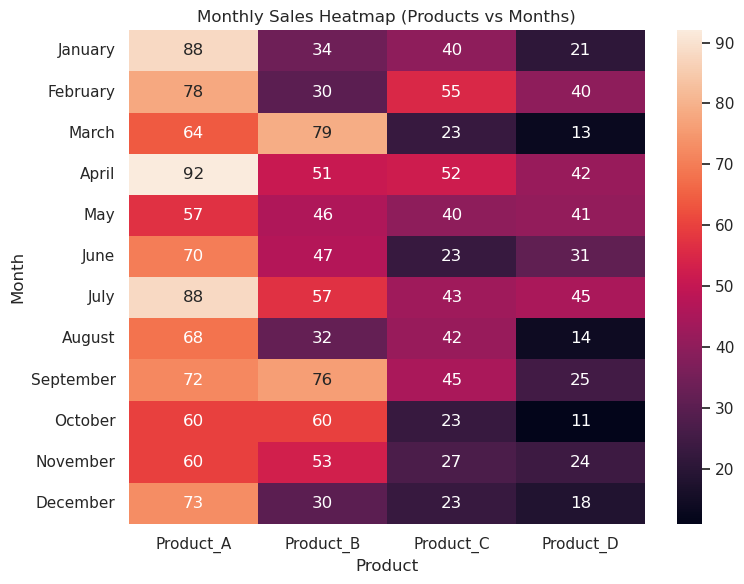

In [45]:
heat_data = df.set_index("Month_Name")[product_cols]

plt.figure(figsize=(8, 6))
sns.heatmap(heat_data, annot=True, fmt="d")
plt.title("Monthly Sales Heatmap (Products vs Months)")
plt.xlabel("Product")
plt.ylabel("Month")
plt.tight_layout()
plt.show()


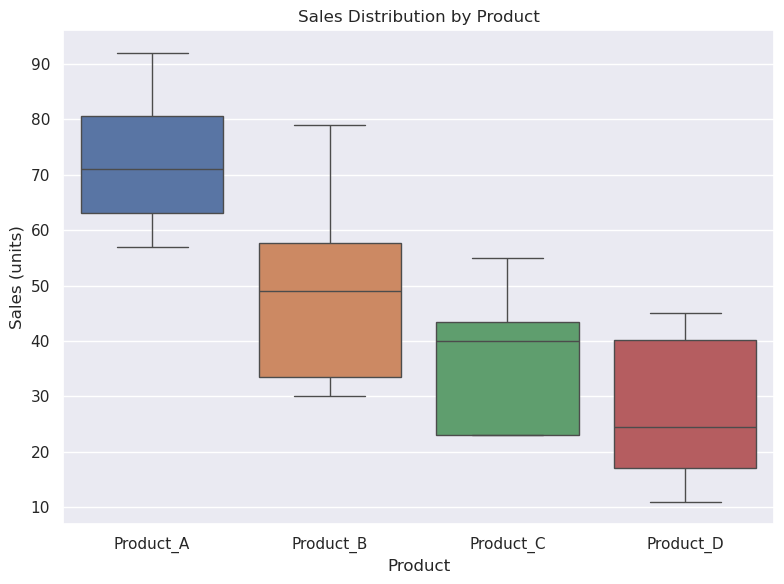

In [46]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df[product_cols])
plt.title("Sales Distribution by Product")
plt.xlabel("Product")
plt.ylabel("Sales (units)")
plt.tight_layout()
plt.show()

In [47]:
total_by_product = df[product_cols].sum()
best_product = total_by_product.idxmax()
best_product_name = best_product.replace("Product_", "")

total_by_product, best_product_name

(Product_A    870
 Product_B    595
 Product_C    436
 Product_D    325
 dtype: int64,
 'A')

In [48]:
quarter_total = df.groupby("Quarter")["Total_Sales"].sum().sort_values(ascending=False)
best_quarter = quarter_total.idxmax()

quarter_total, best_quarter


(Quarter
 Q3    607
 Q2    592
 Q1    565
 Q4    462
 Name: Total_Sales, dtype: int64,
 'Q3')

In [49]:
df["Cumulative_Total_Sales"] = df["Total_Sales"].cumsum()

In [50]:
def rank_products(row):
    return row[product_cols].rank(ascending=False, method="dense")

ranks = df.apply(rank_products, axis=1)
ranks.columns = [col.replace("Product_", "Rank_") for col in product_cols]

df = pd.concat([df, ranks], axis=1)
df.head()

,Date,Product_A,Product_B,Product_C,Product_D,Month_Name,Month_Number,Quarter,Total_Sales,Average_Sales,Month_over_Month_Growth,Cumulative_Total_Sales,Rank_A,Rank_B,Rank_C,Rank_D
0,2025-01-01,88,34,40,21,January,1,Q1,183,45.75,NaN,183,1.0,3.0,2.0,4.0
1,2025-02-01,78,30,55,40,February,2,Q1,203,50.75,10.928962,386,1.0,4.0,2.0,3.0
2,2025-03-01,64,79,23,13,March,3,Q1,179,44.75,-11.822660,565,2.0,1.0,3.0,4.0
3,2025-04-01,92,51,52,42,April,4,Q2,237,59.25,32.402235,802,1.0,3.0,2.0,4.0
4,2025-05-01,57,46,40,41,May,5,Q2,184,46.00,-22.362869,986,1.0,2.0,4.0,3.0
